<h1 style="text-align:center">   
      <font color = White >
            <span style='font-family:Georgia'>
                Credit Card Fraud Detection: Project 4
            </span>   
        </font>    
</h1>
<h3 style="text-align:CENTER">   
      <font color = white >
            <span style='font-family:Georgia'>
                By : Team 9
            </span>   
        </font>    
</h3>
<hr style="width:100%;height:5px;border-width:0;color:gray;background-color:gray">
<center>

## Import Python Libraries:


In [1]:
# Lets import the required libraries and packages
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.metrics import precision_recall_curve, roc_auc_score
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, f1_score
# Lets Supress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Lets import and read the dataset
fraud_test = pd.read_csv("fraudTest.csv")
fraud_test

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


In [3]:
# Lets see the head of our dataset
fraud_test.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [4]:
# Lets check the info to see the types of the feature variables and the null values present
fraud_test.info(verbose=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [5]:
# Lets check the summary of the dataset
fraud_test.describe(include='all')

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,555719,5.557190e+05,555719,555719,555719.000000,555719,555719,555719,555719,...,555719.000000,555719.000000,5.557190e+05,555719,555719,555719,5.557190e+05,555719.000000,555719.000000,555719.000000
unique,NaN,544760,NaN,693,14,NaN,341,471,2,924,...,NaN,NaN,NaN,478,910,555719,NaN,NaN,NaN,NaN
top,NaN,2020-12-19 16:02:22,NaN,fraud_Kilback LLC,gas_transport,NaN,Christopher,Smith,F,444 Robert Mews,...,NaN,NaN,NaN,Film/video editor,1977-03-23,2da90c7d74bd46a0caf3777415b3ebd3,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,1859,56370,NaN,11443,12146,304886,1474,...,NaN,NaN,NaN,4119,2408,1,NaN,NaN,NaN,NaN
mean,277859.000000,NaN,4.178387e+17,NaN,NaN,69.392810,NaN,NaN,NaN,NaN,...,38.543253,-90.231325,8.822189e+04,NaN,NaN,NaN,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,NaN,1.309837e+18,NaN,NaN,156.745941,NaN,NaN,NaN,NaN,...,5.061336,13.721780,3.003909e+05,NaN,NaN,NaN,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,NaN,6.041621e+10,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,20.027100,-165.672300,2.300000e+01,NaN,NaN,NaN,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,NaN,1.800429e+14,NaN,NaN,9.630000,NaN,NaN,NaN,NaN,...,34.668900,-96.798000,7.410000e+02,NaN,NaN,NaN,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,NaN,3.521417e+15,NaN,NaN,47.290000,NaN,NaN,NaN,NaN,...,39.371600,-87.476900,2.408000e+03,NaN,NaN,NaN,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,NaN,4.635331e+15,NaN,NaN,83.010000,NaN,NaN,NaN,NaN,...,41.894800,-80.175200,1.968500e+04,NaN,NaN,NaN,1.385867e+09,41.954163,-80.264637,0.000000


### Duplicate value analysis


In [6]:
# checking duplicates
sum(fraud_test.duplicated(subset = 'cc_num')) == 0

False

In [7]:
# Lets check the dimensions of the dataset
fraud_test.shape

(555719, 23)

In [8]:
fraud_test.drop_duplicates()
fraud_test.shape

(555719, 23)

## Data Cleaning 

### Checking Null Values 


In [10]:
# Lets check the null values present in the dataset
print(round(100*(fraud_test.isnull().sum()/len(fraud_test.index)), 2).sort_values(ascending = False))

Unnamed: 0               0.0
zip                      0.0
merch_long               0.0
merch_lat                0.0
unix_time                0.0
trans_num                0.0
dob                      0.0
job                      0.0
city_pop                 0.0
long                     0.0
lat                      0.0
state                    0.0
trans_date_trans_time    0.0
city                     0.0
street                   0.0
gender                   0.0
last                     0.0
first                    0.0
amt                      0.0
category                 0.0
merchant                 0.0
cc_num                   0.0
is_fraud                 0.0
dtype: float64


### Dropping Unnecessary Columns 


In [11]:
# Lets delete unwanted column
fraud_test= fraud_test.drop(['Unnamed: 0'],axis=1)
fraud_test= fraud_test.drop(['first'],axis=1)
fraud_test= fraud_test.drop(['last'],axis=1)
# Lets again check the dimensions of the dataset
fraud_test.shape

(555719, 20)

In [12]:
# Identifying columns which has only one unique value
print(fraud_test.nunique(dropna=False).sort_values())

is_fraud                      2
gender                        2
category                     14
state                        50
job                         478
merchant                    693
city_pop                    835
city                        849
dob                         910
long                        910
lat                         910
zip                         912
street                      924
cc_num                      924
amt                       37256
unix_time                544760
trans_date_trans_time    544760
merch_lat                546490
merch_long               551770
trans_num                555719
dtype: int64


### Data Manipulation
        

In [13]:
# Lets convert the columns to appropriate formats
fraud_test['trans_date_trans_time']= pd.to_datetime(fraud_test['trans_date_trans_time'])


In [14]:
fraud_test['dob'] = pd.to_datetime(fraud_test['dob'], errors='coerce')

#### Creating two new columns ['trans_Date', 'trans_Time'] from trans_date_trans_time for better understanding

In [15]:
fraud_test['trans_Date']=fraud_test.trans_date_trans_time.dt.date
fraud_test['trans_Time']=fraud_test.trans_date_trans_time.dt.time
fraud_test.trans_Date = pd.to_datetime(fraud_test['trans_Date'],format='%Y-%m-%d')

In [16]:
fraud_test

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_Date,trans_Time
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,M,351 Darlene Green,Columbia,SC,29209,...,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,2020-06-21,12:14:25
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,F,3638 Marsh Union,Altonah,UT,84002,...,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,2020-06-21,12:14:33
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,9333 Valentine Point,Bellmore,NY,11710,...,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,2020-06-21,12:14:53
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,...,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,2020-06-21,12:15:15
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,...,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,2020-06-21,12:15:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,M,558 Michael Estates,Luray,MO,63453,...,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0,2020-12-31,23:59:07
555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,M,572 Davis Mountains,Lake Jackson,TX,77566,...,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0,2020-12-31,23:59:09
555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,F,144 Evans Islands Apt. 683,Burbank,WA,99323,...,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0,2020-12-31,23:59:15
555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,M,7020 Doyle Stream Apt. 951,Mesa,ID,83643,...,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0,2020-12-31,23:59:24


In [17]:
fraud_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   trans_date_trans_time  555719 non-null  datetime64[ns]
 1   cc_num                 555719 non-null  int64         
 2   merchant               555719 non-null  object        
 3   category               555719 non-null  object        
 4   amt                    555719 non-null  float64       
 5   gender                 555719 non-null  object        
 6   street                 555719 non-null  object        
 7   city                   555719 non-null  object        
 8   state                  555719 non-null  object        
 9   zip                    555719 non-null  int64         
 10  lat                    555719 non-null  float64       
 11  long                   555719 non-null  float64       
 12  city_pop               555719 non-null  int6

In [18]:
grp_by_cc=fraud_test.groupby(['cc_num'])
fraudDf=pd.DataFrame(grp_by_cc['is_fraud'].nunique())
fraudDf.shape

(924, 1)

### Checking the Skewness of following variables `'job', 'category', 'state', 'city'`

In [19]:
df=fraud_test[['job', 'category', 'state', 'city']]

for c in df.columns:
    print ("-----------------------------------------------------" )
    print ("---- %s ---" % c)
    print( df[c].value_counts(normalize=True))

-----------------------------------------------------
---- job ---
job
Film/video editor                0.007412
Exhibition designer              0.007140
Surveyor, land/geomatics         0.006759
Naval architect                  0.006748
Designer, ceramics/pottery       0.006232
                                   ...   
Estate manager/land agent        0.000351
Engineer, civil (consulting)     0.000349
Operational investment banker    0.000020
Software engineer                0.000020
Engineer, water                  0.000014
Name: proportion, Length: 478, dtype: float64
-----------------------------------------------------
---- category ---
category
gas_transport     0.101436
grocery_pos       0.094568
home              0.094193
shopping_pos      0.089597
kids_pets         0.087620
shopping_net      0.075180
entertainment     0.072166
personal_care     0.070768
food_dining       0.070662
health_fitness    0.065994
misc_pos          0.062215
misc_net          0.049246
grocery_net     

### Binning of `job` column as it is having `497` unique values

In [20]:
fraud_test['job'].describe()

count                555719
unique                  478
top       Film/video editor
freq                   4119
Name: job, dtype: object

In [21]:
fraud_test['job'][fraud_test['job'].str.contains('(Teacher|teacher|Lecturer|lecturer|Professor|professor)',regex=True)].value_counts()

job
Early years teacher                       2475
Secondary school teacher                  2447
Special educational needs teacher         2184
Teacher, special educational needs        1984
Further education lecturer                1734
English as a second language teacher      1712
Private music teacher                     1558
Lecturer, further education               1544
Lecturer, higher education                1410
Teacher, early years/pre                  1175
Teacher, secondary school                 1106
Teacher, primary school                    723
Teacher, English as a foreign language     460
English as a foreign language teacher      241
TEFL teacher                               227
Professor Emeritus                         224
Primary school teacher                     224
Teacher, adult education                   223
Associate Professor                        204
Name: count, dtype: int64

In [22]:
fraud_test['job'].replace(["Secondary school teacher","Early years teacher","TEFL teacher",
        "Special educational needs teacher","Teacher, special educational needs",
        "Further education lecturer","English as a second language teacher","Associate Professor",
        "Lecturer, further education","Private music teacher","Lecturer, higher education",
        "Teacher, early years/pre","Teacher, secondary school","Teacher, primary school",
        "Teacher, English as a foreign language","Primary school teacher","Professor Emeritus",
        "English as a foreign language teacher","Teacher, adult education"],'Teacher', inplace=True)

In [23]:
fraud_test['job'][fraud_test['job'].str.contains('(Engineering|engineering|Engineer|engineer)',
                                                        regex=True)].value_counts()

job
Materials engineer                       3441
Mining engineer                          2611
Water engineer                           2576
Mechanical engineer                      2430
Engineer, automotive                     2416
Petroleum engineer                       2379
Energy engineer                          2370
Chemical engineer                        2248
Engineer, biomedical                     2210
Drilling engineer                        2189
Electrical engineer                      2122
Engineer, control and instrumentation    1993
Engineer, production                     1952
Engineering geologist                    1769
Structural engineer                      1558
Engineer, mining                         1517
Engineer, electronics                    1495
Engineer, land                           1358
Manufacturing engineer                   1320
Site engineer                            1301
Electronics engineer                     1293
Geologist, engineering        

In [24]:
fraud_test['job'].replace(["Materials engineer","Mining engineer","Water engineer","Engineer, land",
        "Mechanical engineer","Engineer, automotive","Petroleum engineer","Energy engineer",
        "Chemical engineer","Engineer, biomedical","Drilling engineer","Electrical engineer",
        "Engineer, production","Engineer, control and instrumentation","Engineering geologist",
        "Structural engineer","Engineer, mining","Engineer, electronics","Site engineer",
        "Geologist, engineering","Electronics engineer","Manufacturing engineer","Engineer, site",
        "Maintenance engineer","Engineer, petroleum","Communications engineer","Network engineer",
        "Civil engineer, contracting","Engineer, technical sales","Biomedical engineer",
        "Engineer, drilling","Aeronautical engineer","Production engineer","Engineer, maintenance",
        "Engineer, agricultural","Engineer, civil (contracting)","Engineer, communications",
        "Building services engineer","Control and instrumentation engineer","Engineer, structural",
        "Engineer, building services","Manufacturing systems engineer","Engineer, aeronautical",
        "Engineer, broadcasting (operations)","Engineer, manufacturing","Broadcast engineer",
        "Engineer, civil (consulting)","Engineer, materials","Software engineer","Engineer, water",
        'Contracting civil engineer'], 'Engineer', inplace=True)

In [25]:
fraud_test['job'].value_counts(normalize=True)

job
Engineer                         0.106768
Teacher                          0.039327
Film/video editor                0.007412
Exhibition designer              0.007140
Surveyor, land/geomatics         0.006759
                                   ...   
Geneticist, molecular            0.000360
Conservator, furniture           0.000358
Estate manager/land agent        0.000351
Merchandiser, retail             0.000351
Operational investment banker    0.000020
Name: proportion, Length: 412, dtype: float64

In [26]:
fraud_test['job'][fraud_test['job'].str.contains('(Scientist|scientist)',
                                                                        regex=True)].value_counts()

job
Scientist, audiological                                        3060
Audiological scientist                                         2683
Scientist, research (maths)                                    2609
Geoscientist                                                   2421
Scientist, marine                                              2217
Research scientist (physical sciences)                         2134
Scientist, biomedical                                          1732
Product/process development scientist                          1344
Biomedical scientist                                           1304
Soil scientist                                                 1090
Research scientist (life sciences)                              893
Scientist, research (physical sciences)                         871
Scientist, physiological                                        839
Physiological scientist                                         654
Research scientist (maths)                  

In [27]:
fraud_test['job'].replace(["Scientist, audiological","Audiological scientist","Data scientist",
            "Scientist, research (maths)","Geoscientist","Research scientist (physical sciences)",
            "Scientist, marine","Scientist, biomedical","Biomedical scientist",
            "Product/process development scientist","Soil scientist","Scientist, physiological",
            "Research scientist (life sciences)","Scientist, research (physical sciences)",
            "Physiological scientist","Research scientist (maths)","Research scientist (medical)",
            "Scientist, research (medical)","Water quality scientist",
            "Scientist, clinical (histocompatibility and immunogenetics)"],'Scientist', inplace=True)

In [28]:
fraud_test['job'][fraud_test['job'].str.contains('(Officer|officer)',regex=True)].value_counts()

job
Chief Executive Officer                                  3027
Historic buildings inspector/conservation officer        2582
Prison officer                                           2353
Race relations officer                                   1992
Chief Strategy Officer                                   1974
Trading standards officer                                1970
Probation officer                                        1744
Exhibitions officer, museum/gallery                      1697
Research officer, trade union                            1570
Research officer, political party                        1510
Fisheries officer                                        1504
Careers information officer                              1426
Chief Operating Officer                                  1345
Education officer, museum                                1304
Regulatory affairs officer                               1301
Armed forces training and education officer              1133
Wast

In [29]:
fraud_test['job'].replace(['Chief Executive Officer','Armed forces technical officer',
            'Personnel officer','Information officer','Local government officer',"Police officer",
            'Public relations officer','Education officer, community',"Tourism officer",
            'Field trials officer','Charity officer','Nature conservation officer',
            'Environmental education officer',"Environmental education officer",
            "Museum education officer","Medical technical officer","Chief Operating Officer",
           'Race relations officer','Prison officer','Chief Strategy Officer',"Immigration officer", 
            'Probation officer','Exhibitions officer, museum/gallery','Fisheries officer',     
            'Research officer, trade union ','Research officer, political party',   
            "Historic buildings inspector/conservation officer","Trading standards officer",
            "Careers information officer","Regulatory affairs officer","Human resources officer",
            "Armed forces training and education officer","Chief Technology Officer",
            "Chief Financial Officer","Equality and diversity officer","Waste management officer",
            "Chief Marketing Officer","Museum/gallery exhibitions officer",
            "Sports development officer","Arts development officer","Community education officer",
     "Emergency planning/management officer","Armed forces logistics/support/administrative officer",
           "Conservation officer, historic buildings","Training and development officer",
            "Social research officer, government",'Education officer, museum'],
                          'Officer', inplace=True)

In [30]:
fraud_test['job'].value_counts(normalize=True)

job
Engineer                         0.106768
Officer                          0.082266
Scientist                        0.047295
Teacher                          0.039327
Film/video editor                0.007412
                                   ...   
Geneticist, molecular            0.000360
Conservator, furniture           0.000358
Estate manager/land agent        0.000351
Merchandiser, retail             0.000351
Operational investment banker    0.000020
Name: proportion, Length: 352, dtype: float64

In [31]:
fraud_test['job'][fraud_test['job'].str.contains('(Surveyor|surveyor)',regex=True)].value_counts()

job
Surveyor, land/geomatics             3756
Building surveyor                    2608
Land/geomatics surveyor              2448
Quantity surveyor                    2434
Surveyor, minerals                   2037
Insurance risk surveyor              1530
Commercial/residential surveyor      1417
Surveyor, rural practice             1119
Building control surveyor            1109
Rural practice surveyor               671
Surveyor, mining                      637
Planning and development surveyor     620
Hydrographic surveyor                 428
Minerals surveyor                     210
Surveyor, hydrographic                202
Name: count, dtype: int64

In [32]:
fraud_test['job'].replace(["Surveyor, land/geomatics","Building surveyor","Quantity surveyor",
            "Land/geomatics surveyor","Surveyor, minerals","Insurance risk surveyor",
            "Commercial/residential surveyor","Building control surveyor","Surveyor, rural practice",
            "Planning and development surveyor","Surveyor, mining","Rural practice surveyor",
            "Hydrographic surveyor","Minerals surveyor","Surveyor, hydrographic"],
                          'Surveyor', inplace=True)

In [33]:
fraud_test['job'][fraud_test['job'].str.contains('(Designer|designer)',regex=True)].value_counts()

job
Exhibition designer              3968
Designer, ceramics/pottery       3463
Ceramics designer                2076
Designer, industrial/product     1727
Designer, exhibition/display     1352
Designer, furniture              1308
Designer, jewellery              1308
Product designer                 1116
Web designer                     1106
Furniture designer                891
Glass blower/designer             868
Industrial/product designer       843
Set designer                      663
Designer, interior/spatial        636
Jewellery designer                468
Designer, textile                 423
Designer, multimedia              420
Interior and spatial designer     231
Textile designer                  216
Designer, television/film set     206
Name: count, dtype: int64

In [34]:
fraud_test['job'].replace(["Exhibition designer","Designer, ceramics/pottery","Ceramics designer",
            "Designer, industrial/product","Designer, jewellery","Designer, exhibition/display",
            "Designer, furniture","Web designer","Product designer","Glass blower/designer",
            "Furniture designer","Industrial/product designer","Set designer","Designer, textile",
            "Designer, interior/spatial","Jewellery designer","Designer, multimedia",
            "Designer, television/film set","Interior and spatial designer","Textile designer"],
                          'Designer', inplace=True)

In [35]:
fraud_test['job'][fraud_test['job'].str.contains('(manager|Manager)',regex=True)].value_counts()

job
Facilities manager                      1872
Travel agency manager                   1571
Heritage manager                        1553
Call centre manager                     1541
Energy manager                          1474
Production manager                      1330
Leisure centre manager                  1302
Tourist information centre manager      1289
Television floor manager                1255
Fitness centre manager                  1113
Health service manager                  1097
Theme park manager                       931
Information systems manager              912
Farm manager                             899
Public house manager                     878
Pension scheme manager                   828
Location manager                         696
Records manager                          682
Quarry manager                           673
Logistics and distribution manager       646
Theatre manager                          632
Product manager                          454
Outdoo

In [36]:
fraud_test['job'].replace(["Facilities manager","Travel agency manager","Call centre manager",
            "Heritage manager","Production manager","Energy manager","Television floor manager",
            "Leisure centre manager","Tourist information centre manager","Farm manager",
            "Fitness centre manager","Health service manager","Information systems manager",
            "Theme park manager","Pension scheme manager","Public house manager","Quarry manager",
            "Records manager","Logistics and distribution manager","Location manager",
            "Theatre manager","Retail manager","Art gallery manager","Stage manager","Tour manager",
            "Outdoor activities/education manager","Product manager","Hotel manager",
            "Restaurant manager, fast food","Purchasing manager","Catering manager",
            "Environmental manager","Estate manager/land agent","Forest/woodland manager",
                           "Warehouse manager"],'Manager', inplace=True)

In [37]:
fraud_test['job'].value_counts(normalize=True)

job
Engineer                         0.106768
Officer                          0.082266
Manager                          0.048420
Scientist                        0.047295
Designer                         0.041908
                                   ...   
Administrator, arts              0.000362
Geneticist, molecular            0.000360
Conservator, furniture           0.000358
Merchandiser, retail             0.000351
Operational investment banker    0.000020
Name: proportion, Length: 287, dtype: float64

In [38]:
fraud_test['job'][fraud_test['job'].str.contains('(psychologist|Psychologist)',regex=True)].value_counts()

job
Psychologist, forensic              2568
Educational psychologist            2071
Counselling psychologist            1941
Occupational psychologist           1769
Psychologist, counselling           1576
Forensic psychologist               1510
Sport and exercise psychologist      876
Psychologist, sport and exercise     850
Psychologist, clinical               641
Clinical psychologist                454
Name: count, dtype: int64

In [39]:
fraud_test['job'].replace(["Psychologist, forensic","Counselling psychologist",
            "Educational psychologist","Occupational psychologist","Forensic psychologist",
            "Psychologist, counselling","Sport and exercise psychologist",
            "Psychologist, sport and exercise","Psychologist, clinical","Clinical psychologist"],
                          'Psychologist', inplace=True)

In [40]:
fraud_test['job'][fraud_test['job'].str.contains('(editor|Editor)',regex=True)].value_counts()

job
Film/video editor            4119
Magazine features editor     2904
Editor, commissioning        1484
Video editor                 1301
Editor, magazine features     880
Editor, film/video            865
Commissioning editor          680
Name: count, dtype: int64

In [41]:
fraud_test['job'].replace(["Film/video editor","Magazine features editor","Editor, commissioning",
                    "Video editor","Editor, film/video","Editor, magazine features",
                    "Commissioning editor"],'Editor', inplace=True)

In [42]:
fraud_test['job'][fraud_test['job'].str.contains('(Producer|producer)',regex=True)].value_counts()

job
Radio producer                     1973
Television/film/video producer     1735
Producer, radio                    1283
Producer, television/film/video     243
Name: count, dtype: int64

In [43]:
fraud_test['job'].replace(['Radio producer','Television/film/video producer',
                'Producer, television/film/video','Producer, radio'],'Producer', inplace=True)

In [44]:
fraud_test['job'][fraud_test['job'].str.contains('(therapist|Therapist)',regex=True)].value_counts()

job
Psychotherapist, child            2576
Therapist, occupational           2018
Physiotherapist                   1964
Child psychotherapist             1744
Phytotherapist                    1289
Therapist, horticultural          1148
Therapist, art                    1096
Therapist, sports                 1083
Music therapist                   1081
Dance movement psychotherapist     905
Nutritional therapist              874
Psychotherapist                    873
Art therapist                      871
Therapist, drama                   857
Horticultural therapist            847
Therapist, music                   661
Occupational therapist             219
Name: count, dtype: int64

In [45]:
fraud_test['job'].replace(["Psychotherapist, child","Therapist, occupational","Physiotherapist",
                "Child psychotherapist","Phytotherapist","Therapist, horticultural","Therapist, art",
                "Therapist, sports","Music therapist","Horticultural therapist","Art therapist",
                "Nutritional therapist","Dance movement psychotherapist","Psychotherapist",
                "Therapist, drama","Therapist, music","Occupational therapist"],
                          'Therapist', inplace=True)

In [46]:
fraud_test['job'][fraud_test['job'].str.contains('(nurse|Nurse)',regex=True)].value_counts()

job
Learning disability nurse    1547
Paediatric nurse             1118
Mental health nurse          1105
Nurse, children's            1095
Psychiatric nurse             648
Nurse, mental health          446
Name: count, dtype: int64

In [47]:
fraud_test['job'].replace(["Learning disability nurse","Nurse, children's","Paediatric nurse",
                    "Mental health nurse","Psychiatric nurse","Nurse, mental health"],
                          'Nurse', inplace=True)

In [48]:
fraud_test['job'].value_counts(normalize=True)

job
Engineer                         0.106768
Officer                          0.082266
Manager                          0.048420
Scientist                        0.047295
Designer                         0.041908
                                   ...   
Administrator, arts              0.000362
Geneticist, molecular            0.000360
Conservator, furniture           0.000358
Merchandiser, retail             0.000351
Operational investment banker    0.000020
Name: proportion, Length: 248, dtype: float64

In [49]:
fraud_test['job'][fraud_test['job'].str.contains('(assistant|Assistant)',regex=True)].value_counts()

job
Television production assistant     2179
Radio broadcast assistant           1999
Politician's assistant               877
Production assistant, radio          435
Production assistant, television     207
Name: count, dtype: int64

In [50]:
fraud_test['job'].replace(["Television production assistant","Radio broadcast assistant",
                    "Politician's assistant","Production assistant, radio",
                    "Production assistant, television"], 'Assistant', inplace=True)

In [51]:
fraud_test['job'][fraud_test['job'].str.contains('(executive|Executive)',regex=True)].value_counts()

job
Public relations account executive               1808
Sales executive                                   652
Advertising account executive                     640
Chartered legal executive (England and Wales)     441
Marketing executive                               228
Name: count, dtype: int64

In [52]:
fraud_test['job'].replace(["Public relations account executive","Advertising account executive",
                    "Sales executive","Chartered legal executive (England and Wales)",
                    "Marketing executive","Sales promotion account executive"],
                          'Executive', inplace=True)

In [53]:
fraud_test['job'][fraud_test['job'].str.contains('(librarian|Librarian)',regex=True)].value_counts()

job
Librarian, public      2587
Librarian, academic    2104
Public librarian        669
Academic librarian      426
Name: count, dtype: int64

In [54]:
fraud_test['job'].replace(["Librarian, public","Librarian, academic","Public librarian",
                           "Academic librarian"], 'Librarian', inplace=True)

In [55]:
fraud_test['job'][fraud_test['job'].str.contains('(researcher|Researcher)',regex=True)].value_counts()

job
Social researcher                                1971
Programme researcher, broadcasting/film/video    1682
Operational researcher                           1091
Market researcher                                1062
Telecommunications researcher                     842
Name: count, dtype: int64

In [56]:
fraud_test['job'].replace(["Social researcher","Programme researcher, broadcasting/film/video",
                    "Market researcher","Operational researcher","Telecommunications researcher"],
                          'Researcher', inplace=True)

In [57]:
fraud_test['job'][fraud_test['job'].str.contains('(consultant|Consultant)',regex=True)].value_counts()

job
Environmental consultant     3427
Agricultural consultant      2858
Pensions consultant          2532
Public affairs consultant     911
Management consultant         664
IT consultant                 458
Horticultural consultant      213
Name: count, dtype: int64

In [58]:
fraud_test['job'].replace(["Environmental consultant","Agricultural consultant","IT consultant",
                    "Pensions consultant","Public affairs consultant","Management consultant",
                    "Horticultural consultant"], 'Consultant', inplace=True)

In [59]:
fraud_test['job'][fraud_test['job'].str.contains('(conservator|Conservator)',regex=True)].value_counts()

job
Museum/gallery conservator        868
Furniture conservator/restorer    413
Conservator, museum/gallery       229
Conservator, furniture            199
Name: count, dtype: int64

In [60]:
fraud_test['job'].replace(["Museum/gallery conservator","Furniture conservator/restorer",
                "Conservator, museum/gallery","Conservator, furniture"], 'Conservator', inplace=True)

In [61]:
fraud_test['job'][fraud_test['job'].str.contains('(banker|Banker)',regex=True)].value_counts()

job
Investment banker, corporate      901
Corporate investment banker       894
Retail banker                     870
Investment banker, operational    223
Operational investment banker      11
Name: count, dtype: int64

In [62]:
fraud_test['job'].replace(["Investment banker, corporate","Corporate investment banker",
                "Retail banker","Investment banker, operational","Operational investment banker"], 
                'Banker', inplace=True)

In [63]:
fraud_test['job'][fraud_test['job'].str.contains('(chemist|Chemist)',regex=True)].value_counts()

job
Geochemist              1147
Clinical biochemist      866
Chemist, analytical      451
Biochemist, clinical     434
Analytical chemist       236
Name: count, dtype: int64

In [64]:
fraud_test['job'].replace(["Geochemist","Clinical biochemist","Biochemist, clinical",
                    "Chemist, analytical","Analytical chemist"], 'Chemist', inplace=True)

In [65]:
fraud_test['job'][fraud_test['job'].str.contains('(Accountant|accountant)',regex=True)].value_counts()

job
Chartered public finance accountant     3001
Accountant, chartered public finance    1077
Chartered accountant                     702
Accountant, chartered certified          217
Name: count, dtype: int64

In [66]:
fraud_test['job'].replace(["Chartered public finance accountant","Chartered accountant",
                    "Accountant, chartered public finance","Accountant, chartered certified",
                    "Accountant, chartered"], 'Chartered Accountant', inplace=True)

In [67]:
fraud_test['job'][fraud_test['job'].str.contains('(administrator|Administrator)',regex=True)].value_counts()

job
Administrator                                       1511
Administrator, charities/voluntary organisations    1138
Administrator, education                            1101
Database administrator                              1097
Administrator, local government                     1072
Secretary/administrator                              877
Education administrator                              439
Sports administrator                                 412
Civil Service administrator                          233
Administrator, arts                                  201
Name: count, dtype: int64

In [68]:
fraud_test['job'].replace(["Administrator","Administrator, local government",
                "Administrator, education","Administrator, charities/voluntary organisations",
                "Database administrator","Secretary/administrator","Sports administrator",
                "Education administrator","Civil Service administrator","Administrator, arts"], 
                          'Administrator', inplace=True)

In [69]:
fraud_test['job'][fraud_test['job'].str.contains('(Writer|writer)',regex=True)].value_counts()

job
Copywriter, advertising    3095
Science writer             2171
Insurance underwriter      2131
Advertising copywriter      435
Writer                      237
Name: count, dtype: int64

In [70]:
fraud_test['job'].replace(["Copywriter, advertising","Science writer","Insurance underwriter",
                    "Advertising copywriter","Writer"], 'Writer', inplace=True)

In [71]:
fraud_test['job'].value_counts(normalize=True)

job
Engineer                        0.106768
Officer                         0.082266
Manager                         0.048420
Scientist                       0.047295
Designer                        0.041908
                                  ...   
Community development worker    0.000387
Oncologist                      0.000380
Magazine journalist             0.000380
Geneticist, molecular           0.000360
Merchandiser, retail            0.000351
Name: proportion, Length: 200, dtype: float64

In [72]:
fraud_test['job'][fraud_test['job'].str.contains('(Doctor|doctor|Surgeon|surgeon)',regex=True)].value_counts()

job
Surgeon                     1714
Hospital doctor             1554
Tree surgeon                1261
Doctor, hospital            1094
Doctor, general practice    1067
General practice doctor      933
Neurosurgeon                 833
Name: count, dtype: int64

In [73]:
fraud_test['job'].replace(["Surgeon","Hospital doctor","Doctor, general practice","Doctor, hospital",
                "Tree surgeon","Neurosurgeon","Veterinary surgeon","General practice doctor"], 
                          'Doctor', inplace=True)

In [74]:
fraud_test['job'][fraud_test['job'].str.contains('(buyer|Buyer)',regex=True)].value_counts()

job
Buyer, industrial    1755
Media buyer          1090
Retail buyer          839
Buyer, retail         238
Name: count, dtype: int64

In [75]:
fraud_test['job'].replace(["Buyer, industrial","Media buyer","Retail buyer","Buyer, retail","Industrial buyer"], 
                                                                                  'Buyer', inplace=True)

In [76]:
fraud_test['job'][fraud_test['job'].str.contains('(Geneticist|geneticist)',regex=True)].value_counts()

job
Cytogeneticist              2209
Plant breeder/geneticist     406
Clinical cytogeneticist      236
Geneticist, molecular        200
Name: count, dtype: int64

In [77]:
fraud_test['job'].replace(["Cytogeneticist","Plant breeder/geneticist","Geneticist, molecular",
                        "Clinical cytogeneticist"], 'Geneticist', inplace=True)

In [78]:
fraud_test['job'][fraud_test['job'].str.contains('(pharmacist|Pharmacist)',regex=True)].value_counts()

job
Pharmacist, community    900
Community pharmacist     654
Hospital pharmacist      431
Pharmacist, hospital     424
Name: count, dtype: int64

In [79]:
fraud_test['job'].replace(["Pharmacist, community","Community pharmacist","Pharmacist, hospital",
                           "Hospital pharmacist"], 'Pharmacist', inplace=True)

In [80]:
fraud_test['job'][fraud_test['job'].str.contains('(physicist|Physicist)',regex=True)].value_counts()

job
Physicist, medical                 1530
Health physicist                   1340
Geophysicist/field seismologist     667
Medical physicist                   618
Name: count, dtype: int64

In [81]:
fraud_test['job'].replace(["Physicist, medical","Health physicist","Medical physicist",
                           "Geophysicist/field seismologist"], 'Physicist', inplace=True)

In [82]:
fraud_test['job'][fraud_test['job'].str.contains('(analyst|Analyst)',regex=True)].value_counts()

job
Systems analyst         1537
Intelligence analyst    1143
Investment analyst      1124
Risk analyst            1070
Name: count, dtype: int64

In [83]:
fraud_test['job'].replace(["Systems analyst","Risk analyst","Investment analyst","Intelligence analyst"], 
                                                                          'Analyst', inplace=True)

In [84]:
fraud_test['job'][fraud_test['job'].str.contains('(technologist|Technologist)',regex=True)].value_counts()

job
Clothing/textile technologist    2716
Colour technologist              1620
Animal technologist               875
Garment/textile technologist      658
Architectural technologist        442
Name: count, dtype: int64

In [85]:
fraud_test['job'].replace(["Clothing/textile technologist","Colour technologist","Animal technologist",
                "Garment/textile technologist","Architectural technologist"], 'Technologist', inplace=True)

In [86]:
fraud_test['job'][fraud_test['job'].str.contains('(technician|Technician)',regex=True)].value_counts()

job
Accounting technician               1922
Scientific laboratory technician     902
Teaching laboratory technician       691
Name: count, dtype: int64

In [87]:
fraud_test['job'].replace(["Accounting technician","Scientific laboratory technician",
                           "Teaching laboratory technician"], 'Technician', inplace=True)

In [88]:
fraud_test['job'][fraud_test['job'].str.contains('(horticulturist|Horticulturist)',regex=True)].value_counts()

job
Amenity horticulturist        1566
Commercial horticulturist     1349
Horticulturist, commercial     891
Name: count, dtype: int64

In [89]:
fraud_test['job'].replace(['Amenity horticulturist','Commercial horticulturist','Horticulturist, commercial'], 
                                                                      'Horticulturist', inplace=True)

fraud_test['job'].replace(['Retail merchandiser','Merchandiser, retail','Visual merchandiser'], 
                                                                      'Merchandiser', inplace=True)

fraud_test['job'].replace(['Cabin crew','Air cabin crew'],'Cabin crew', inplace=True)

In [90]:
fraud_test['job'].value_counts(normalize=True)

job
Engineer                        0.106768
Officer                         0.082266
Manager                         0.048420
Scientist                       0.047295
Designer                        0.041908
                                  ...   
Artist                          0.000394
Lawyer                          0.000390
Community development worker    0.000387
Oncologist                      0.000380
Magazine journalist             0.000380
Name: proportion, Length: 168, dtype: float64

In [91]:
job_freqs = fraud_test.job.value_counts(normalize=True)

In [92]:
job_freqs.cumsum()

job
Engineer                        0.106768
Officer                         0.189034
Manager                         0.237455
Scientist                       0.284750
Designer                        0.326658
                                  ...   
Artist                          0.998463
Lawyer                          0.998854
Community development worker    0.999241
Oncologist                      0.999620
Magazine journalist             1.000000
Name: proportion, Length: 168, dtype: float64

### Lets see the unique values which explains 90% of the variable `job`

In [93]:
top_jobs = job_freqs.cumsum()[:91].index
top_jobs

Index(['Engineer', 'Officer', 'Manager', 'Scientist', 'Designer', 'Teacher',
       'Surveyor', 'Therapist', 'Psychologist', 'Editor', 'Consultant',
       'Doctor', 'Administrator', 'Writer', 'Researcher', 'Technologist',
       'Nurse', 'Librarian', 'Assistant', 'Producer', 'Chartered Accountant',
       'Analyst', 'Physicist', 'Buyer', 'Horticulturist', 'Executive',
       'Naval architect', 'Technician', 'Financial adviser', 'IT trainer',
       'Systems developer', 'Chemist', 'Geneticist', 'Banker', 'Podiatrist',
       'Paramedic', 'Sub', 'Comptroller', 'Immunologist', 'Barrister',
       'Musician', 'Sales professional, IT', 'Counsellor', 'Firefighter',
       'Pharmacist', 'Make', 'Claims inspector/assessor', 'Financial trader',
       'Merchandiser', 'Trade mark attorney', 'Medical sales representative',
       'Chartered loss adjuster', 'Fine artist', 'Technical brewer', 'Dealer',
       'Toxicologist', 'Multimedia programmer', 'Archaeologist',
       'Press photographer', 'P

In [94]:
fraud_test['job'].value_counts(normalize=True)

job
Engineer                        0.106768
Officer                         0.082266
Manager                         0.048420
Scientist                       0.047295
Designer                        0.041908
                                  ...   
Artist                          0.000394
Lawyer                          0.000390
Community development worker    0.000387
Oncologist                      0.000380
Magazine journalist             0.000380
Name: proportion, Length: 168, dtype: float64

In [95]:
fraud_test['job'].describe()

count       555719
unique         168
top       Engineer
freq         59333
Name: job, dtype: object

In [96]:
fraud_test.shape

(555719, 22)

### Binning of `state` column as it is having 51 unique values

In [97]:
def label_states (row):
    if row['state'] in ['CT','ME','MA','NH','NJ','NY','PA','RI','VT']:
        return 'Northeast'
    if row['state'] in ['IL','IN','IA','KS','MI','MN','MO','NE','ND','OH','SD','WI']:
        return 'Midwest'
    if row['state'] in ['AL','AR','DE','DC','FL','GA','KY','LA','MD','MS','NC','OK','SC','TN','Tx','VA','WV']:
        return 'South'
    else:
        return 'West'

In [98]:
fraud_test['state_bin'] = fraud_test.apply(lambda row: label_states(row), axis=1)
fraud_test

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_Date,trans_Time,state_bin
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,M,351 Darlene Green,Columbia,SC,29209,...,Engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,2020-06-21,12:14:25,South
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,F,3638 Marsh Union,Altonah,UT,84002,...,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,2020-06-21,12:14:33,West
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,9333 Valentine Point,Bellmore,NY,11710,...,Librarian,1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,2020-06-21,12:14:53,Northeast
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,...,Designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,2020-06-21,12:15:15,South
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,...,Designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,2020-06-21,12:15:17,Midwest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,M,558 Michael Estates,Luray,MO,63453,...,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0,2020-12-31,23:59:07,Midwest
555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,M,572 Davis Mountains,Lake Jackson,TX,77566,...,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0,2020-12-31,23:59:09,West
555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,F,144 Evans Islands Apt. 683,Burbank,WA,99323,...,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0,2020-12-31,23:59:15,West
555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,M,7020 Doyle Stream Apt. 951,Mesa,ID,83643,...,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0,2020-12-31,23:59:24,West


In [99]:
fraud_test["state_bin"].describe()

count     555719
unique         4
top        South
freq      170884
Name: state_bin, dtype: object

## Feature Engineering


### Deriving `age` on transaction day from "dob" variable and binning of age variable

In [100]:

fraud_test["age"] = fraud_test["dob"].apply(lambda x: (pd.to_datetime('now').year - x.year))


### Binning of age variable for better insights

In [101]:
bin_manual = [0, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labs = ['0-20', '20-30', '30-40', '40-50','50-60','60-70','70-80', '80-90','90-100']
fraud_test['age_bin'] = pd.cut(fraud_test.age, bins=bin_manual, labels=labs)

In [102]:
fraud_test[['age_bin','age']].head()

,age_bin,age
0,50-60,56
1,30-40,34
2,50-60,54
3,30-40,37
4,60-70,69


In [103]:
fraud_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   trans_date_trans_time  555719 non-null  datetime64[ns]
 1   cc_num                 555719 non-null  int64         
 2   merchant               555719 non-null  object        
 3   category               555719 non-null  object        
 4   amt                    555719 non-null  float64       
 5   gender                 555719 non-null  object        
 6   street                 555719 non-null  object        
 7   city                   555719 non-null  object        
 8   state                  555719 non-null  object        
 9   zip                    555719 non-null  int64         
 10  lat                    555719 non-null  float64       
 11  long                   555719 non-null  float64       
 12  city_pop               555719 non-null  int6

###  Deriving `trans_Year`, `trans_year_month`, `trans_Month`, `trans_Hour`, `trans_Day`, `trans_weekday` of transaction from trans_date_trans_time variable

In [104]:
fraud_test['trans_Year']=fraud_test.trans_Date.dt.year
fraud_test['trans_year_month'] = fraud_test.trans_Date.dt.to_period('M')
fraud_test['trans_Month']=fraud_test.trans_Date.dt.month
fraud_test['trans_Hour']=fraud_test.trans_date_trans_time.dt.hour
fraud_test['trans_Day']=fraud_test.trans_Date.dt.day
fraud_test['trans_weekday'] = fraud_test.trans_Date.dt.day_name()

fraud_test

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,trans_Time,state_bin,age,age_bin,trans_Year,trans_year_month,trans_Month,trans_Hour,trans_Day,trans_weekday
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,M,351 Darlene Green,Columbia,SC,29209,...,12:14:25,South,56,50-60,2020,2020-06,6,12,21,Sunday
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,F,3638 Marsh Union,Altonah,UT,84002,...,12:14:33,West,34,30-40,2020,2020-06,6,12,21,Sunday
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,9333 Valentine Point,Bellmore,NY,11710,...,12:14:53,Northeast,54,50-60,2020,2020-06,6,12,21,Sunday
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,...,12:15:15,South,37,30-40,2020,2020-06,6,12,21,Sunday
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,...,12:15:17,Midwest,69,60-70,2020,2020-06,6,12,21,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,M,558 Michael Estates,Luray,MO,63453,...,23:59:07,Midwest,58,50-60,2020,2020-12,12,23,31,Thursday
555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,M,572 Davis Mountains,Lake Jackson,TX,77566,...,23:59:09,West,25,20-30,2020,2020-12,12,23,31,Thursday
555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,F,144 Evans Islands Apt. 683,Burbank,WA,99323,...,23:59:15,West,43,40-50,2020,2020-12,12,23,31,Thursday
555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,M,7020 Doyle Stream Apt. 951,Mesa,ID,83643,...,23:59:24,West,59,50-60,2020,2020-12,12,23,31,Thursday


### Deriving `dis` i.e. distance between credit card lat, long to merchant lat and long

In [105]:
from math import radians, cos, sin, asin, sqrt 

def haversine_distance(lat, long, merch_lat, merch_long): 
      
    # The math module contains a function named 
    # radians which converts from degrees to radians. 
    long = np.radians(long) 
    merch_long = np.radians(merch_long) 
    lat = np.radians(lat) 
    merch_lat = np.radians(merch_lat) 
       
    # Haversine formula  
    dlon = merch_long - long  
    dlat = merch_lat - lat
    a = np.sin(dlat / 2)**2 + np.cos(lat) * np.cos(merch_lat) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)) 
    #c = 2 * np.arctan2(a**0.5, (1-a)**0.5)
    
    # Radius of earth in kilometers.  
    r = 6371
    d=  c * r
    # calculate the result 
    return round(d,2)

In [106]:
fraud_test['dist']=fraud_test[['lat', 'long', 'merch_lat', 'merch_long']].apply(
                                        lambda x:haversine_distance(x[0], x[1], x[2], x[3]), axis=1)

In [107]:
fraud_test

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,state_bin,age,age_bin,trans_Year,trans_year_month,trans_Month,trans_Hour,trans_Day,trans_weekday,dist
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,M,351 Darlene Green,Columbia,SC,29209,...,South,56,50-60,2020,2020-06,6,12,21,Sunday,24.56
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,F,3638 Marsh Union,Altonah,UT,84002,...,West,34,30-40,2020,2020-06,6,12,21,Sunday,104.93
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,9333 Valentine Point,Bellmore,NY,11710,...,Northeast,54,50-60,2020,2020-06,6,12,21,Sunday,59.08
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,...,South,37,30-40,2020,2020-06,6,12,21,Sunday,27.70
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,...,Midwest,69,60-70,2020,2020-06,6,12,21,Sunday,104.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,M,558 Michael Estates,Luray,MO,63453,...,Midwest,58,50-60,2020,2020-12,12,23,31,Thursday,77.03
555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,M,572 Davis Mountains,Lake Jackson,TX,77566,...,West,25,20-30,2020,2020-12,12,23,31,Thursday,100.07
555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,F,144 Evans Islands Apt. 683,Burbank,WA,99323,...,West,43,40-50,2020,2020-12,12,23,31,Thursday,80.76
555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,M,7020 Doyle Stream Apt. 951,Mesa,ID,83643,...,West,59,50-60,2020,2020-12,12,23,31,Thursday,52.93


### Deriving `prev_merch_lat`, `prev_merch_long` i.e Previous longitude/latitude of merchant and `time_since_prev_transaction` i.e time since previous transaction in hours

In [108]:
# Get previous longitude/latitude and time elapsed of a transaction
fraud_test['prev_merch_lat']=grp_by_cc['merch_lat'].transform(lambda x:x.shift(1)).fillna(
                                                                        fraud_test['merch_lat'])
fraud_test['prev_merch_long']=grp_by_cc['merch_long'].transform(lambda x:x.shift(1)).fillna(
                                                                        fraud_test['merch_long'])
# Time since previous transaction in hours
fraud_test['time_since_prev_transaction'] = grp_by_cc['trans_Hour'].transform(lambda x:round(
                                                                     (x-x.shift(1)),1)).fillna(0)

In [109]:
fraud_test

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,trans_Year,trans_year_month,trans_Month,trans_Hour,trans_Day,trans_weekday,dist,prev_merch_lat,prev_merch_long,time_since_prev_transaction
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,M,351 Darlene Green,Columbia,SC,29209,...,2020,2020-06,6,12,21,Sunday,24.56,33.986391,-81.200714,0.0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,F,3638 Marsh Union,Altonah,UT,84002,...,2020,2020-06,6,12,21,Sunday,104.93,39.450498,-109.960431,0.0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,9333 Valentine Point,Bellmore,NY,11710,...,2020,2020-06,6,12,21,Sunday,59.08,40.495810,-74.196111,0.0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,...,2020,2020-06,6,12,21,Sunday,27.70,28.812398,-80.883061,0.0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,...,2020,2020-06,6,12,21,Sunday,104.34,44.959148,-85.884734,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,M,558 Michael Estates,Luray,MO,63453,...,2020,2020-12,12,23,31,Thursday,77.03,40.395006,-91.537312,4.0
555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,M,572 Davis Mountains,Lake Jackson,TX,77566,...,2020,2020-12,12,23,31,Thursday,100.07,28.599619,-95.170763,2.0
555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,F,144 Evans Islands Apt. 683,Burbank,WA,99323,...,2020,2020-12,12,23,31,Thursday,80.76,45.716706,-119.886246,0.0
555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,M,7020 Doyle Stream Apt. 951,Mesa,ID,83643,...,2020,2020-12,12,23,31,Thursday,52.93,45.152800,-116.250539,3.0


### Deriving `distance_between_merchants` by calculating distance between current and previous purchase location

In [110]:
fraud_test['distance_between_merchants']=fraud_test.apply(lambda x:haversine_distance(
                                            x.prev_merch_lat,x.prev_merch_long,x.merch_lat,x.merch_long), axis=1)

In [111]:
fraud_test

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,trans_year_month,trans_Month,trans_Hour,trans_Day,trans_weekday,dist,prev_merch_lat,prev_merch_long,time_since_prev_transaction,distance_between_merchants
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,M,351 Darlene Green,Columbia,SC,29209,...,2020-06,6,12,21,Sunday,24.56,33.986391,-81.200714,0.0,0.00
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,F,3638 Marsh Union,Altonah,UT,84002,...,2020-06,6,12,21,Sunday,104.93,39.450498,-109.960431,0.0,0.00
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,9333 Valentine Point,Bellmore,NY,11710,...,2020-06,6,12,21,Sunday,59.08,40.495810,-74.196111,0.0,0.00
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,...,2020-06,6,12,21,Sunday,27.70,28.812398,-80.883061,0.0,0.00
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,...,2020-06,6,12,21,Sunday,104.34,44.959148,-85.884734,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,M,558 Michael Estates,Luray,MO,63453,...,2020-12,12,23,31,Thursday,77.03,40.395006,-91.537312,4.0,52.76
555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,M,572 Davis Mountains,Lake Jackson,TX,77566,...,2020-12,12,23,31,Thursday,100.07,28.599619,-95.170763,2.0,153.84
555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,F,144 Evans Islands Apt. 683,Burbank,WA,99323,...,2020-12,12,23,31,Thursday,80.76,45.716706,-119.886246,0.0,105.53
555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,M,7020 Doyle Stream Apt. 951,Mesa,ID,83643,...,2020-12,12,23,31,Thursday,52.93,45.152800,-116.250539,3.0,100.23


### Checking the correlations between the variables


In [112]:
fraud_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 36 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   trans_date_trans_time        555719 non-null  datetime64[ns]
 1   cc_num                       555719 non-null  int64         
 2   merchant                     555719 non-null  object        
 3   category                     555719 non-null  object        
 4   amt                          555719 non-null  float64       
 5   gender                       555719 non-null  object        
 6   street                       555719 non-null  object        
 7   city                         555719 non-null  object        
 8   state                        555719 non-null  object        
 9   zip                          555719 non-null  int64         
 10  lat                          555719 non-null  float64       
 11  long                      

In [113]:
# lets check the correlation amongst the features
# Select only the numeric columns
numeric_cols = fraud_test.select_dtypes(include=[np.number])

# Compute the correlation matrix
cor = numeric_cols.corr()

# Display the correlation matrix
print(cor)


                               cc_num       amt       zip       lat      long  \
cc_num                       1.000000  0.001963  0.041610 -0.057512 -0.048783   
amt                          0.001963  1.000000  0.002310  0.002339 -0.002046   
zip                          0.041610  0.002310  1.000000 -0.115173 -0.909942   
lat                         -0.057512  0.002339 -0.115173  1.000000 -0.012892   
long                        -0.048783 -0.002046 -0.909942 -0.012892  1.000000   
city_pop                    -0.009414  0.002760  0.075571 -0.152666 -0.051524   
unix_time                   -0.000810 -0.000974  0.001395  0.000301 -0.001460   
merch_lat                   -0.057183  0.002404 -0.114809  0.993557 -0.012551   
merch_long                  -0.048818 -0.002053 -0.909117 -0.012831  0.999115   
is_fraud                    -0.001540  0.182267 -0.002271  0.005863 -0.000972   
age                          0.000203 -0.012865  0.008823  0.045446 -0.027613   
trans_Year                  

### Dropping the variables who have high correlation values


In [114]:
fraud_test= fraud_test.drop(['prev_merch_lat','prev_merch_long','merch_lat','merch_long','zip'],axis=1)
fraud_test= fraud_test.drop(['age_bin','trans_Date','unix_time', 'trans_Day','trans_year_month'],axis=1)
fraud_test= fraud_test.drop(['trans_Time','trans_date_trans_time','dob', 'state_bin'],axis=1)

fraud_test.shape

(555719, 22)

In [115]:
fraud_test.columns

Index(['cc_num', 'merchant', 'category', 'amt', 'gender', 'street', 'city',
       'state', 'lat', 'long', 'city_pop', 'job', 'trans_num', 'is_fraud',
       'age', 'trans_Year', 'trans_Month', 'trans_Hour', 'trans_weekday',
       'dist', 'time_since_prev_transaction', 'distance_between_merchants'],
      dtype='object')

In [116]:
fraud_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   cc_num                       555719 non-null  int64  
 1   merchant                     555719 non-null  object 
 2   category                     555719 non-null  object 
 3   amt                          555719 non-null  float64
 4   gender                       555719 non-null  object 
 5   street                       555719 non-null  object 
 6   city                         555719 non-null  object 
 7   state                        555719 non-null  object 
 8   lat                          555719 non-null  float64
 9   long                         555719 non-null  float64
 10  city_pop                     555719 non-null  int64  
 11  job                          555719 non-null  object 
 12  trans_num                    555719 non-null  object 
 13 

### Label encoding


In [117]:
from sklearn.preprocessing import LabelEncoder
def preprocess_data(X):
# Convert categorical columns if any
    label_encoders = {}
    for col in X.columns:
        if X[col].dtype == 'object':
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col])
            label_encoders[col] = le
    
    return X, label_encoders

# Preprocess the data
X_train_preprocessed, label_encoders = preprocess_data(fraud_test)

In [118]:
X_train_preprocessed

,cc_num,merchant,category,amt,gender,street,city,state,lat,long,...,trans_num,is_fraud,age,trans_Year,trans_Month,trans_Hour,trans_weekday,dist,time_since_prev_transaction,distance_between_merchants
0,2291163933867244,319,10,2.86,1,341,157,39,33.9659,-80.9355,...,98699,0,56,2020,6,12,3,24.56,0.0,0.00
1,3573030041201292,591,10,29.84,0,354,16,43,40.3207,-110.4360,...,108785,0,34,2020,6,12,3,104.93,0.0,0.00
2,3598215285024754,611,5,41.28,0,865,61,33,40.6729,-73.5365,...,433979,0,54,2020,6,12,3,59.08,0.0,0.00
3,3591919803438423,222,9,60.05,1,320,764,8,28.5697,-80.8191,...,71993,0,37,2020,6,12,3,27.70,0.0,0.00
4,3526826139003047,292,13,3.19,1,548,247,21,44.2529,-85.0170,...,190585,0,69,2020,6,12,3,104.34,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,30560609640617,507,5,43.77,1,531,443,23,40.4931,-91.8912,...,336391,0,58,2020,12,23,4,77.03,4.0,52.76
555715,3556613125071656,264,7,111.84,1,540,401,42,29.0393,-95.4401,...,70372,0,25,2020,12,23,4,100.07,2.0,153.84
555716,6011724471098086,496,7,86.88,0,126,104,46,46.1966,-118.9017,...,235088,0,43,2020,12,23,4,80.76,0.0,105.53
555717,4079773899158,75,13,7.99,1,663,476,12,44.6255,-116.4493,...,43546,0,59,2020,12,23,4,52.93,3.0,100.23


### Splitting the Data into X & Y


In [131]:
from sklearn.model_selection import train_test_split

# Putting feature variable to X
X = X_train_preprocessed.drop(['is_fraud','cc_num', 'trans_num'],axis=1)

# Putting response variable to y
y = X_train_preprocessed['is_fraud']

In [120]:
X.shape, y.shape

((555719, 19), (555719,))

## Model Prediction

### Loading required libraries 

In [132]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_curve, auc, classification_report, confusion_matrix
import gc  # for deleting unused variables


In [137]:
import joblib


# Step 1: Load the saved model and scaler
model_filename = 'xmodelingLR.joblib'
scaler_filename = 'scalerLR.joblib'

logreg_best = joblib.load(model_filename)
scaler = joblib.load(scaler_filename)

In [138]:
from sklearn.preprocessing import StandardScaler


In [139]:
X_test_scaled = scaler.transform(X)

In [141]:

y_test_pred_logreg = logreg_best.predict(X_test_scaled)


In [142]:
 #Model evaluation metrics
print('Accuracy: ', '{:.1%}'.format(accuracy_score(y, y_test_pred_logreg)))
print('F1 score: ', '{:.1%}'.format(f1_score(y, y_test_pred_logreg)))
print('Recall: ', '{:.1%}'.format(recall_score(y, y_test_pred_logreg)))
print('Precision: ', '{:.1%}'.format(precision_score(y, y_test_pred_logreg)))


Accuracy:  94.4%
F1 score:  8.5%
Recall:  67.9%
Precision:  4.5%


ROC for the test dataset: 84.2%


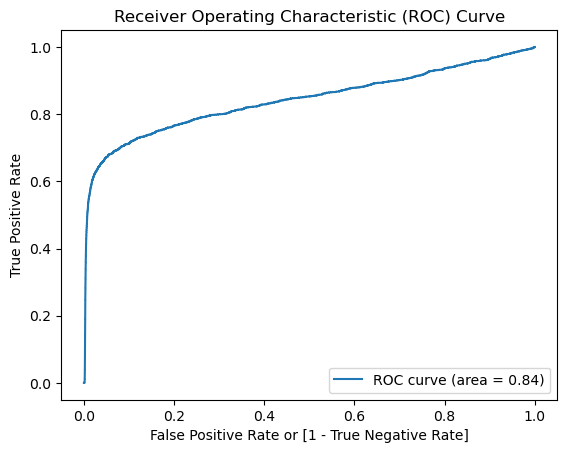

In [143]:
# ROC and AUC
pred_probs_test = logreg_best.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, threshold = roc_curve(y, pred_probs_test)
roc_auc = auc(fpr, tpr)
print("ROC for the test dataset:", "{:.1%}".format(roc_auc))

plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc=4)
plt.show()

In [144]:
# Confusion Matrix
print('\nConfusion Matrix:\n', confusion_matrix(y, y_test_pred_logreg))
confusion_logreg = confusion_matrix(y, y_test_pred_logreg)

TN = confusion_logreg[0, 0]  # true negatives 
TP = confusion_logreg[1, 1]  # true positives
FP = confusion_logreg[0, 1]  # false positives
FN = confusion_logreg[1, 0]  # false negatives

# Sensitivity, Specificity, FPR, PPV, NPV
print("Sensitivity: ", '{:.1%}'.format(TP / float(TP + FN)))
print("Specificity: ", '{:.1%}'.format(TN / float(TN + FP)))
print("False Positive Rate:", '{:.1%}'.format(FP / float(TN + FP)))
print("Positive Predictive Value:", '{:.1%}'.format(TP / float(TP + FP)))
print("Negative Predictive Value:", '{:.1%}'.format(TN / float(TN + FN)))

# Generate Classification Report
print('\nClassification Report:\n', classification_report(y, y_test_pred_logreg))


Confusion Matrix:
 [[522984  30590]
 [   688   1457]]
Sensitivity:  67.9%
Specificity:  94.5%
False Positive Rate: 5.5%
Positive Predictive Value: 4.5%
Negative Predictive Value: 99.9%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97    553574
           1       0.05      0.68      0.09      2145

    accuracy                           0.94    555719
   macro avg       0.52      0.81      0.53    555719
weighted avg       1.00      0.94      0.97    555719



In [146]:
# Final evaluation metrics
print('\nBest Model Evaluation Metrics:')
print('Accuracy: ', '{:.1%}'.format(accuracy_score(y, y_test_pred_logreg)))
print('F1 score: ', '{:.1%}'.format(f1_score(y, y_test_pred_logreg)))
print('Recall: ', '{:.1%}'.format(recall_score(y, y_test_pred_logreg)))
print('Precision: ', '{:.1%}'.format(precision_score(y, y_test_pred_logreg)))
print('\nClassification Report:\n', classification_report(y, y_test_pred_logreg))
print('\nConfusion Matrix:\n', confusion_matrix(y, y_test_pred_logreg))


Best Model Evaluation Metrics:
Accuracy:  94.4%
F1 score:  8.5%
Recall:  67.9%
Precision:  4.5%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97    553574
           1       0.05      0.68      0.09      2145

    accuracy                           0.94    555719
   macro avg       0.52      0.81      0.53    555719
weighted avg       1.00      0.94      0.97    555719


Confusion Matrix:
 [[522984  30590]
 [   688   1457]]


In [147]:
confusion_lr= confusion_matrix( y, y_test_pred_logreg)

TN = confusion_lr[0,0] # true negatives 
TP = confusion_lr[1,1] # true positives
FP = confusion_lr[0,1] # false positives
FN = confusion_lr[1,0] # false negatives

# Let's see the sensitivity of our logistic regression model
print("Sensitivity: " ,'{:.1%}'.format(TP / float(TP+FN)))

# Let us calculate specificity
print("Specificity: " ,'{:.1%}'.format(TN / float(TN+FP)))

# Calculate false postive rate - predicting churn when customer does not have churned
print("False postive rate:" ,'{:.1%}'.format(FP/ float(TN+FP)))

# positive predictive value 
print("Positive predictive value:" ,'{:.1%}'.format(TP / float(TP+FP)))

# Negative predictive value
print("Negative predictive value:" ,'{:.1%}'.format(TN / float(TN+ FN)))

Sensitivity:  67.9%
Specificity:  94.5%
False postive rate: 5.5%
Positive predictive value: 4.5%
Negative predictive value: 99.9%
